# Phase 2: Causal Modeling with DoWhy

This notebook implements the DoWhy causal modeling framework based on the Phase 1 extracted data (`data/scm_train.parquet`).

## 1. Setup and Imports
Suppress verbose logging to keep the notebook clean.

In [ ]:
import warnings
import logging
import pandas as pd

import sys
from pathlib import Path
_cwd = Path.cwd()
_root = _cwd.parent if _cwd.name == "notebooks" else _cwd
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.causal_model.graph import build_causal_graph_gml
from src.causal_model.model import create_causal_model, identify_effect, estimate_ate_ipw, estimate_ate_linear, positivity_check
from src.causal_model.refutation import run_refutations
from src.causal_model.cdi import compute_cdi_batch
import dowhy
print(f'DoWhy Version: {dowhy.__version__}')

warnings.filterwarnings('ignore')
logging.getLogger('dowhy').setLevel(logging.WARNING)
logging.getLogger('statsmodels').setLevel(logging.WARNING)


c:\Users\abhis\Code\Programs\Personal-Projects\causal_rs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DoWhy Version: 0.14


## 2. Load Data & Define Graph
Load `scm_train.parquet` and define the tiered GML causal graph.

In [ ]:
data_path = str(_root / 'data' / 'scm_train.parquet')
try:
    df = pd.read_parquet(data_path)
    print(f'Loaded Phase 1 data: {len(df)} records.')
except FileNotFoundError:
    print(f'Warning: {data_path} not found. Please run Phase 1 data pipeline first.')
    df = pd.DataFrame()

u_pca_cols = [col for col in df.columns if col.startswith('U_pca_')] if not df.empty else ['U_pca_0']
causal_graph_gml = build_causal_graph_gml(u_pca_cols)


Loaded Phase 1 data: 60410 records.


## 3. Instantiate CausalModel
Initialize the model with the loaded data and visualize it to confirm the graph parsed correctly.

In [ ]:
if not df.empty:
    common_causes = [col for col in df.columns if col.startswith('U_pca_')]
    common_causes += ['U_dwell_mean', 'I_category', 'I_sentiment']
    model = create_causal_model(
        df=df, treatment='A', outcome='Y_diversity',
        graph_gml=causal_graph_gml, common_causes=common_causes,
    )
    try:
        model.view_model(layout='dot')
    except Exception as e:
        print('Note: Install system graphviz package to view the graph visualization natively.')
else:
    print('Cannot instantiate CausalModel: data is empty.')


Note: Install system graphviz package to view the graph visualization natively.


## 4. Identify Causal Effect
Ensure DoWhy can find a non-parametric ATE using standard Backdoor adjustment.

In [ ]:
if not df.empty:
    estimand = identify_effect(model)
    print(estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d                                                                             ↪
────(E[Y_diversity|U_pca_22,U_pca_6,U_pca_0,U_pca_4,U_pca_2,U_pca_21,U_pca_10, ↪
d[A]                                                                           ↪

↪                                                                              ↪
↪ U_pca_25,U_pca_31,U_pca_8,I_sentiment,U_pca_13,U_pca_3,U_pca_30,U_pca_1,U_pc ↪
↪                                                                              ↪

↪                                                                              ↪
↪ a_29,U_dwell_mean,U_pca_5,U_pca_17,U_pca_20,U_pca_26,U_pca_7,U_pca_14,U_pca_ ↪
↪                                                                              ↪

↪                                                                              ↪
↪ 16,U_pca_18,U_pca_19,U_pca_9,U_pca_27,U_pca_11,U_pca_28,I_category,U_pca_23,

## 5. Positivity Check
Manually inspect the overlap of Propensity Scores between Treatment and Control before inverse weighting.

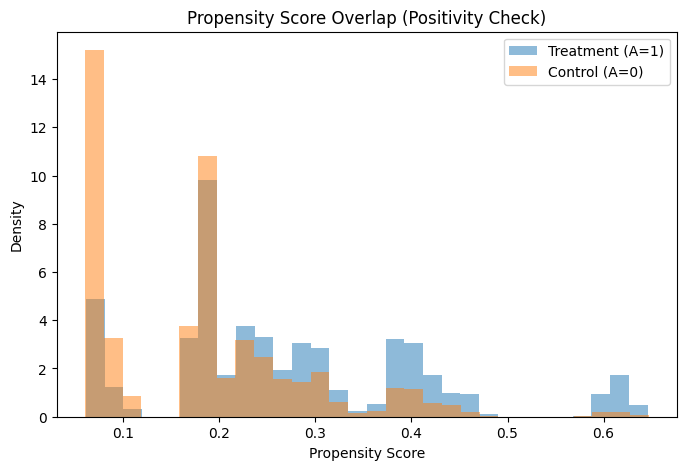

In [ ]:
if not df.empty:
    common_causes = [col for col in df.columns if col.startswith('U_pca_')]
    common_causes += ['U_dwell_mean', 'I_category', 'I_sentiment']
    ps = positivity_check(df, common_causes)


## 6. Effect Estimation (ATE) - IPW & Linear Regression
Using Propensity Score Weighting with clipping (`min_ps_threshold`, `max_ps_threshold`) to prevent exploding variance from extreme scores.

In [ ]:
if not df.empty:
    estimate_ipw = estimate_ate_ipw(model, estimand)
    print(f'ATE (IPW): {estimate_ipw.value:.4f}')
    estimate_lr = estimate_ate_linear(model, estimand)
    print(f'ATE (Linear Regression): {estimate_lr.value:.4f}')


ATE (IPW): -0.0094
ATE (Linear Regression): -0.0098


## 7. Individual Treatment Effects (ITE) -> Causal Diversity Impact (CDI)
Compute the impact of exposure on diversity at the item-user level.

In [ ]:
if not df.empty:
    if 'user_id' in df.columns and 'item_id' in df.columns:
        sample_df = df.head(10).copy()
        try:
            cdi_scores = compute_cdi_batch(model, estimand, sample_df)
            print('Sample CDI Scores (Proxy via ATE without EconML):')
            for k, v in list(cdi_scores.items())[:3]:
                print(f'> User {k[0]} -> Item {k[1]}: {v:.4f}')
        except Exception as e:
            print('Could not compute ITE:', e)
    else:
        print('Data missing user_id or item_id columns.')


Sample CDI Scores (Proxy via ATE without EconML):
> User U13740 -> Item N55689: -0.0098
> User U13740 -> Item N35729: -0.0098
> User U13740 -> Item N39693: -0.0098


## 8. Refutation Checks
Perform robustness checks. A warning is logged on failure, rather than hard-failing to allow iterative diagnosis.

In [ ]:
if not df.empty:
    print('--- Starting Refutations ---')
    results = run_refutations(model, estimand, estimate_ipw)
    print('\nRefutation checks completed.')


--- Starting Refutations ---

1. Placebo Treatment:
 Refute: Use a Placebo Treatment
Estimated effect:-0.009415558097536247
New effect:0.005227862832813046
p value:8.521677070993809e-12


2. Data Subset:
 Refute: Use a subset of data
Estimated effect:-0.009415558097536247
New effect:-0.009302749569137781
p value:0.40740461229202923


3. Random Common Cause:
 Refute: Add a random common cause
Estimated effect:-0.009415558097536247
New effect:-0.009415558097536247
p value:nan


Refutation checks completed.


: 